# Data Analysis



In [3]:
from pathlib import Path
import networkx as nx
import pandas as pd
import numpy as np

FOLDER = Path('./asnr datasets')
assert FOLDER.exists(), f"Dataset folder not found: {FOLDER}"

#read graphs into dict
asnr_graphs: dict[str, nx.Graph] = {}
for fp in FOLDER.glob('*.graphml'):
    asnr_graphs[fp.stem + '.graphml'] = nx.read_graphml(fp)

#read information
info_frame = pd.read_csv(FOLDER / 'Network_summary_masterfile.csv')

#chosen classes/interactions
selected_classes = ['Mammalia', 'Insecta', 'Aves']
selected_interactions = [
    'physical_contact',
    'social_projection_bipartite',
    'spatial_proximity',
    'grooming',
    'dominance',
    'FE_mating',
]

filtered_df = (
    info_frame[
        info_frame['interaction_type'].isin(selected_interactions) &
        info_frame['class'].isin(selected_classes) &
        (info_frame['nodes'] > 5) &
        pd.notna(info_frame['avg.edge.strength'])
    ]
    .copy()
    .rename(columns={'class': 'network_class'})
    .reset_index(drop=True)
)

interaction_mapping = {c: i for i, c in enumerate(selected_interactions)}
bio_class_mapping   = {c: i for i, c in enumerate(selected_classes)}
filtered_df['interaction_map'] = filtered_df['interaction_type'].map(interaction_mapping)

bio_inv         = {v: k for k, v in bio_class_mapping.items()}
interaction_inv = {v: k for k, v in interaction_mapping.items()}
bio_names       = [bio_inv[i] for i in sorted(bio_inv)]

print(f"Loaded {len(asnr_graphs)} graphs | Filtered: {len(filtered_df)}")


Loaded 1197 graphs | Filtered: 924


## Structural feature computation

In [4]:
import matplotlib.pyplot as plt

def compute_graph_features(graph):
    G = graph.to_undirected() if graph.is_directed() else graph
    degrees = [d for _, d in G.degree()]
    try:
        avg_clustering = nx.average_clustering(G)
    except Exception:
        avg_clustering = float('nan')
    try:
        if nx.is_connected(G):
            avg_path = nx.average_shortest_path_length(G)
        else:
            lcc = G.subgraph(max(nx.connected_components(G), key=len))
            avg_path = nx.average_shortest_path_length(lcc)
    except Exception:
        avg_path = float('nan')
    return {
        'n_nodes': G.number_of_nodes(), 'n_edges': G.number_of_edges(),
        'mean_degree': np.mean(degrees), 'std_degree': np.std(degrees),
        'density': nx.density(G), 'avg_clustering': avg_clustering,
        'avg_path_length': avg_path,
    }

feature_rows = []
for _, row in filtered_df.iterrows():
    nid = row['Network_ID']
    if nid not in asnr_graphs: continue
    feats = compute_graph_features(asnr_graphs[nid])
    feats['Network_ID'] = nid
    feats['class'] = row['network_class']
    feats['interaction_type'] = row['interaction_type']
    feature_rows.append(feats)

feat_df = pd.DataFrame(feature_rows)
print("Median structural features by biological class:")
print(feat_df.groupby('class')[
    ['mean_degree','density','avg_clustering','avg_path_length']
].median().round(3))


Median structural features by biological class:
          mean_degree  density  avg_clustering  avg_path_length
class                                                          
Aves             6.00    0.529           0.702            1.400
Insecta         66.09    0.693           0.790            1.307
Mammalia         3.75    0.220           0.526            2.066


## Distributions by biological class

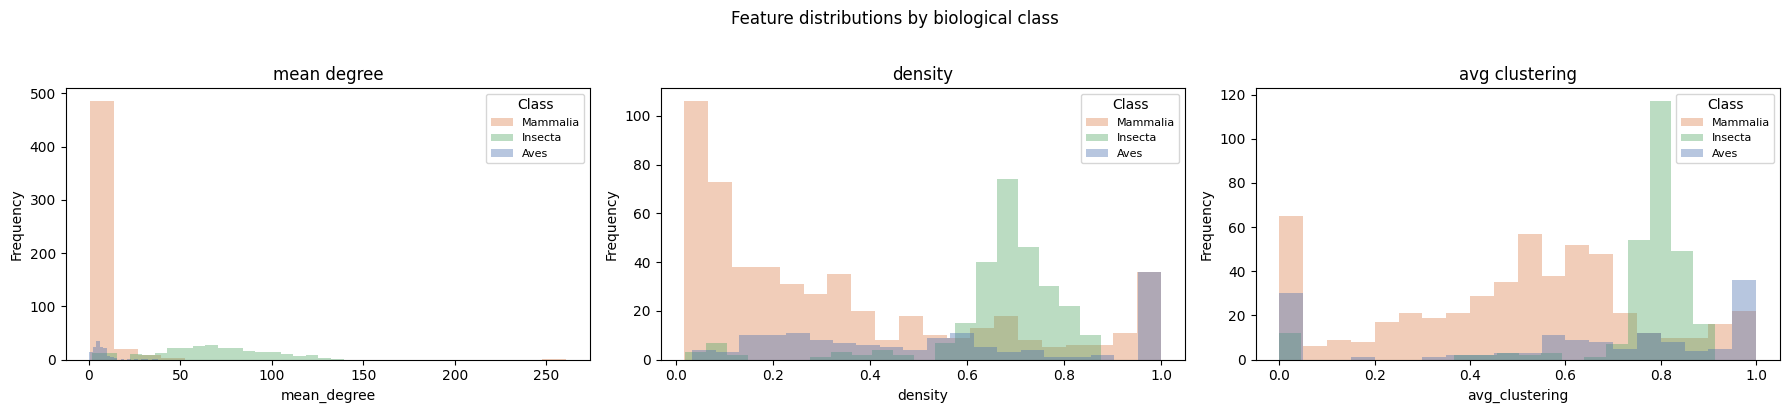

In [5]:
FEATURES = ['mean_degree','density','avg_clustering']
CLASS_COLORS = {'Mammalia':'#DD8452','Insecta':'#55A868','Aves':'#4C72B0'}

fig, axes = plt.subplots(1, len(FEATURES), figsize=(18, 4))
for ax, feat in zip(axes, FEATURES):
    for cls in selected_classes:
        ax.hist(feat_df[feat_df['class']==cls][feat].dropna(),
                bins=20, alpha=0.4, label=cls, color=CLASS_COLORS[cls])
    ax.set_title(feat.replace('_',' ')); ax.set_xlabel(feat); ax.set_ylabel('Frequency')
    ax.legend(title='Class', fontsize=8)
plt.suptitle('Feature distributions by biological class', y=1.02)
plt.tight_layout(); 
plt.show()


C:\Users\BetterOffBread\AppData\Local\Temp\ipykernel_60720\1839510699.py:5: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(data, labels=['Aves','Mammalia', 'Insecta'], patch_artist=True)
C:\Users\BetterOffBread\AppData\Local\Temp\ipykernel_60720\1839510699.py:5: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(data, labels=['Aves','Mammalia', 'Insecta'], patch_artist=True)
C:\Users\BetterOffBread\AppData\Local\Temp\ipykernel_60720\1839510699.py:5: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(data, labels=['Aves','Mammalia', 'Insecta'], patch_artist=True)


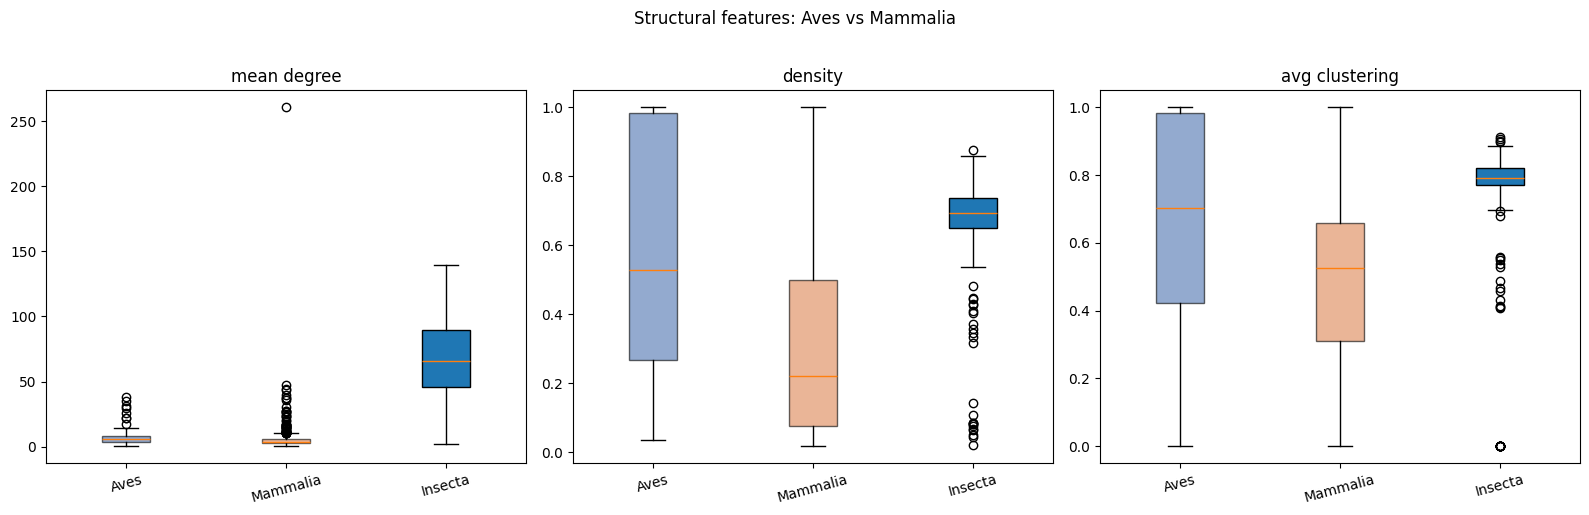

In [6]:
# Box plots
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
for ax, feat in zip(axes, FEATURES):
    data = [feat_df[feat_df['class']==c][feat].dropna().values for c in ['Aves','Mammalia','Insecta']]
    bp = ax.boxplot(data, labels=['Aves','Mammalia', 'Insecta'], patch_artist=True)
    for patch, cls in zip(bp['boxes'], ['Aves','Mammalia']):
        patch.set_facecolor(CLASS_COLORS[cls]); patch.set_alpha(0.6)
    ax.set_title(feat.replace('_',' ')); ax.tick_params(axis='x', rotation=15)
plt.suptitle('Structural features: Aves vs Mammalia', y=1.02)
plt.tight_layout(); 
plt.show()


## Distributions by interaction type

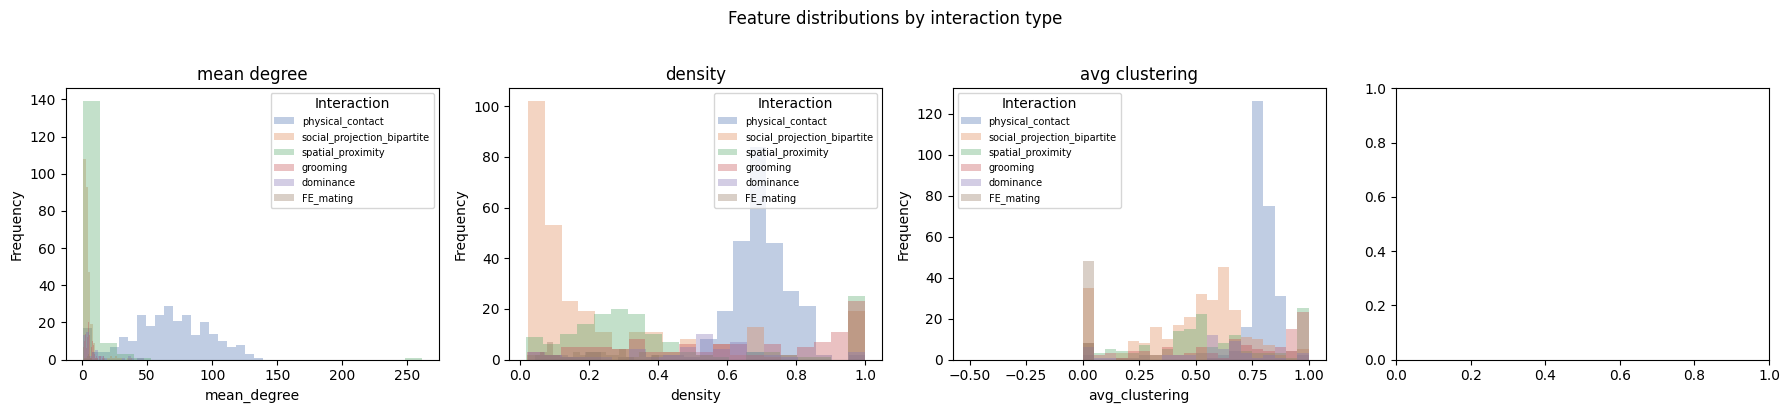

In [7]:
INTERACTION_COLORS = {
    'physical_contact':'#4C72B0','social_projection_bipartite':'#DD8452',
    'spatial_proximity':'#55A868','grooming':'#C44E52',
    'dominance':'#8172B2','FE_mating':'#937860',
}

fig, axes = plt.subplots(1, 4, figsize=(18, 4))
for ax, feat in zip(axes, FEATURES):
    for itype in selected_interactions:
        ax.hist(feat_df[feat_df['interaction_type']==itype][feat].dropna(),
                bins=20, alpha=0.35, label=itype, color=INTERACTION_COLORS[itype])
    ax.set_title(feat.replace('_',' ')); ax.set_xlabel(feat); ax.set_ylabel('Frequency')
    ax.legend(title='Interaction', fontsize=7)
plt.suptitle('Feature distributions by interaction type', y=1.02)
plt.tight_layout(); 
plt.show()


C:\Users\BetterOffBread\AppData\Local\Temp\ipykernel_60720\664035821.py:5: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(data, labels=selected_interactions, patch_artist=True)
C:\Users\BetterOffBread\AppData\Local\Temp\ipykernel_60720\664035821.py:5: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(data, labels=selected_interactions, patch_artist=True)
C:\Users\BetterOffBread\AppData\Local\Temp\ipykernel_60720\664035821.py:5: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(data, labels=selected_interactions, patch_artist=True)


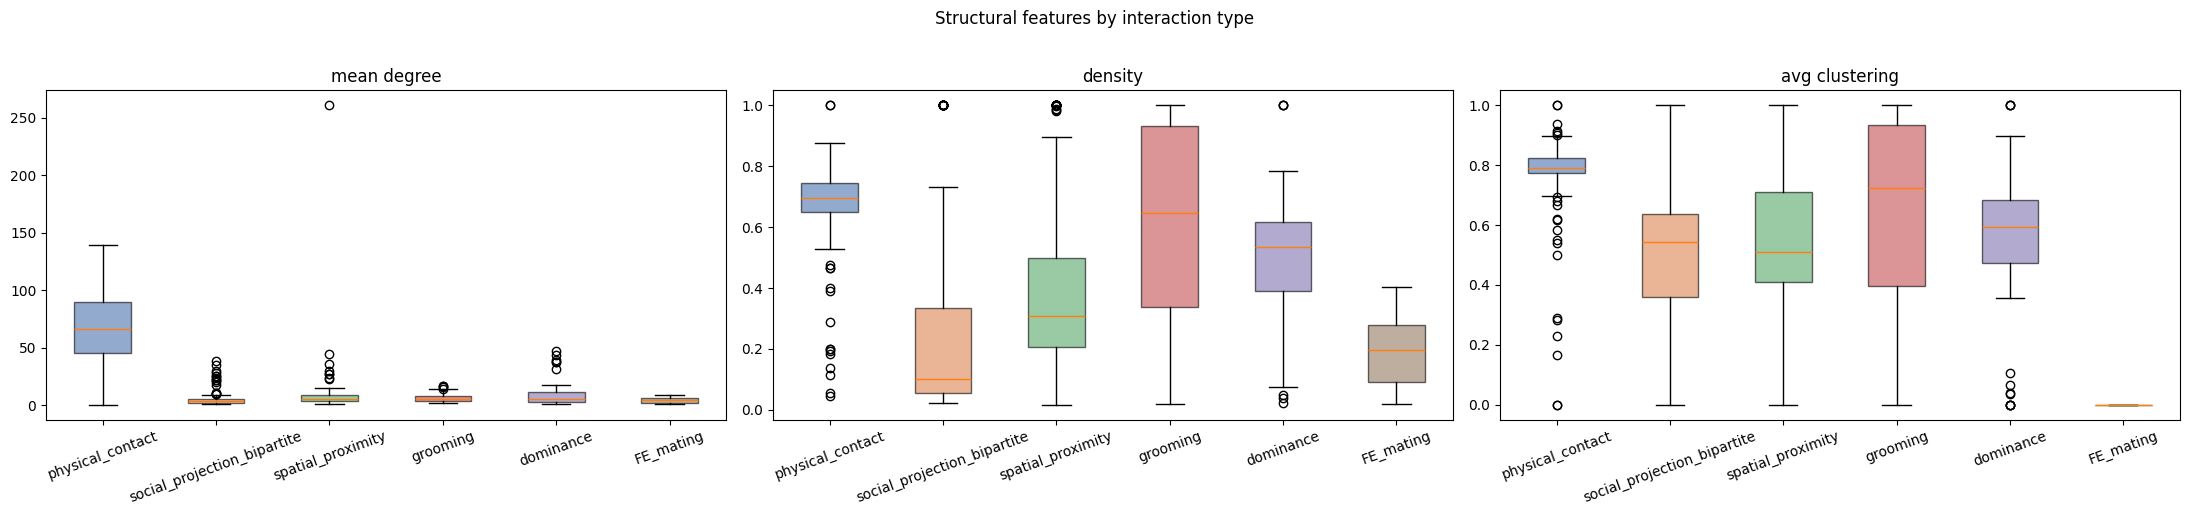

In [8]:


fig, axes = plt.subplots(1, 3, figsize=(22, 5))
for ax, feat in zip(axes, FEATURES):
    data = [feat_df[feat_df['interaction_type']==t][feat].dropna().values
            for t in selected_interactions]
    bp = ax.boxplot(data, labels=selected_interactions, patch_artist=True)
    for patch, itype in zip(bp['boxes'], selected_interactions):
        patch.set_facecolor(INTERACTION_COLORS[itype]); patch.set_alpha(0.6)
    ax.set_title(feat.replace('_',' ')); ax.tick_params(axis='x', rotation=20)
plt.suptitle('Structural features by interaction type', y=1.02)
plt.tight_layout(); 
plt.show()


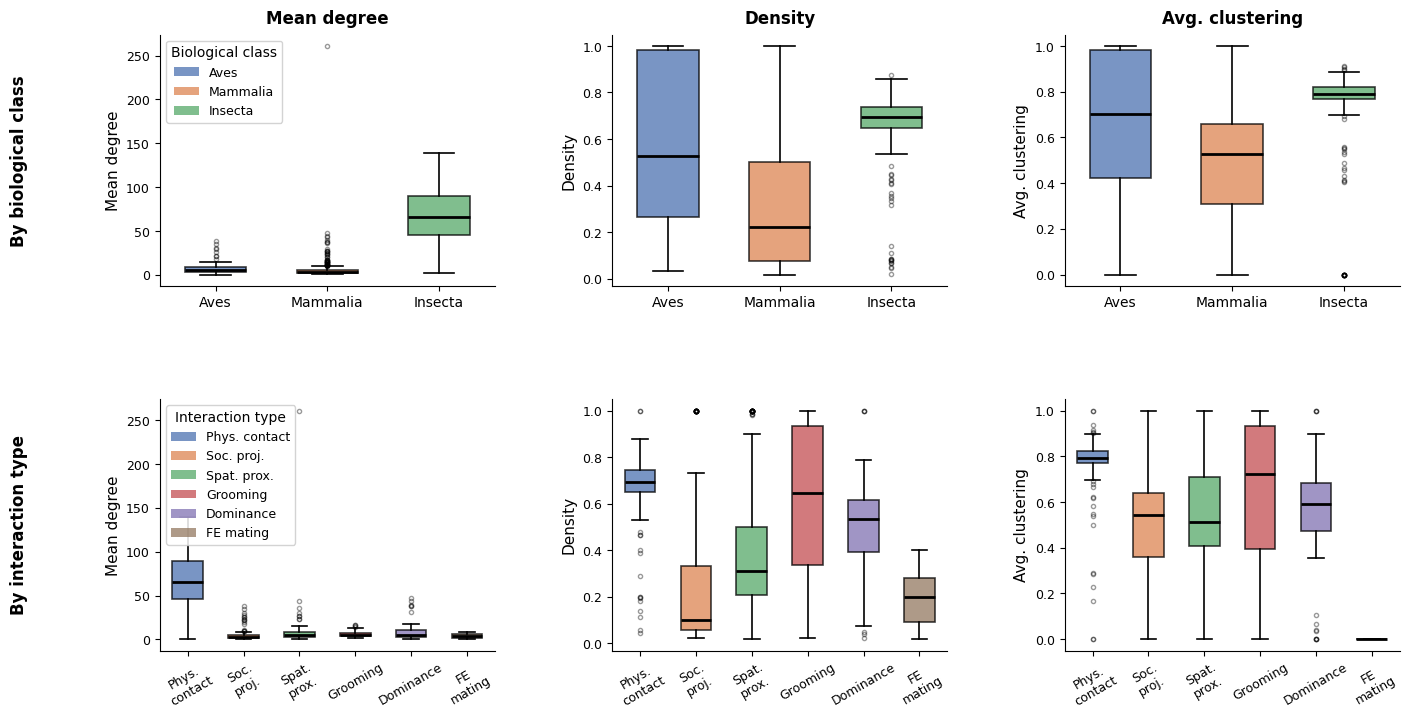

In [9]:
# Short labels for compact display
CLASS_SHORT = {'Aves': 'Aves', 'Mammalia': 'Mammalia', 'Insecta': 'Insecta'}
INT_SHORT_LABELS = {
    'physical_contact':            'Phys.\ncontact',
    'social_projection_bipartite': 'Soc.\nproj.',
    'spatial_proximity':           'Spat.\nprox.',
    'grooming':                    'Grooming',
    'dominance':                   'Dominance',
    'FE_mating':                   'FE\nmating',
}
FEATURE_LABELS = {
    'mean_degree':     'Mean degree',
    'density':         'Density',
    'avg_clustering':  'Avg. clustering',
    'avg_path_length': 'Avg. path length',
}
FEATURES = ['mean_degree', 'density', 'avg_clustering']

fig, axes = plt.subplots(2, 3, figsize=(16, 8))
fig.subplots_adjust(hspace=0.45, wspace=0.35)

bio_classes   = ['Aves', 'Mammalia', 'Insecta']
int_types     = selected_interactions
int_labels    = [INT_SHORT_LABELS[t] for t in int_types]

for col, feat in enumerate(FEATURES):

    ax = axes[0, col]
    data = [feat_df[feat_df['class'] == c][feat].dropna().values
            for c in bio_classes]
    bp = ax.boxplot(data, patch_artist=True, widths=0.55,
                    medianprops=dict(color='black', linewidth=2),
                    whiskerprops=dict(linewidth=1.2),
                    capprops=dict(linewidth=1.2),
                    flierprops=dict(marker='o', markersize=3,
                                   alpha=0.4, linestyle='none'))
    for patch, cls in zip(bp['boxes'], bio_classes):
        patch.set_facecolor(CLASS_COLORS[cls])
        patch.set_alpha(0.75)
        patch.set_linewidth(1.2)

    ax.set_xticks(range(1, len(bio_classes) + 1))
    ax.set_xticklabels(bio_classes, fontsize=10)
    ax.set_ylabel(FEATURE_LABELS[feat], fontsize=11)
    ax.tick_params(axis='y', labelsize=9)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

    ax = axes[1, col]
    data = [feat_df[feat_df['interaction_type'] == t][feat].dropna().values
            for t in int_types]
    bp = ax.boxplot(data, patch_artist=True, widths=0.55,
                    medianprops=dict(color='black', linewidth=2),
                    whiskerprops=dict(linewidth=1.2),
                    capprops=dict(linewidth=1.2),
                    flierprops=dict(marker='o', markersize=3,
                                   alpha=0.4, linestyle='none'))
    for patch, itype in zip(bp['boxes'], int_types):
        patch.set_facecolor(INTERACTION_COLORS[itype])
        patch.set_alpha(0.75)
        patch.set_linewidth(1.2)

    ax.set_xticks(range(1, len(int_types) + 1))
    ax.set_xticklabels(int_labels, fontsize=9, ha='center', rotation=30)
    ax.set_ylabel(FEATURE_LABELS[feat], fontsize=11)
    ax.tick_params(axis='y', labelsize=9)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)


for row, label in enumerate(['By biological class', 'By interaction type']):
    axes[row, 0].annotate(
        label, xy=(-0.42, 0.5), xycoords='axes fraction',
        fontsize=12, fontweight='bold', ha='center', va='center',
        rotation=90,
    )


for col, feat in enumerate(FEATURES):
    axes[0, col].set_title(FEATURE_LABELS[feat], fontsize=12,
                           fontweight='bold', pad=8)


from matplotlib.patches import Patch

bio_legend = [Patch(facecolor=CLASS_COLORS[c], alpha=0.75, label=c)
              for c in bio_classes]
int_legend = [Patch(facecolor=INTERACTION_COLORS[t], alpha=0.75,
                    label=INT_SHORT_LABELS[t].replace('\n', ' '))
              for t in int_types]

axes[0, 0].legend(handles=bio_legend, title='Biological class',
                  fontsize=9, title_fontsize=10,
                  loc='upper left', framealpha=0.85)
axes[1, 0].legend(handles=int_legend, title='Interaction type',
                  fontsize=9, title_fontsize=10,
                  loc='upper left', framealpha=0.85)

plt.savefig('eda_boxplots_combined.pdf', bbox_inches='tight', dpi=300)
plt.show()

## Example graph visualisations

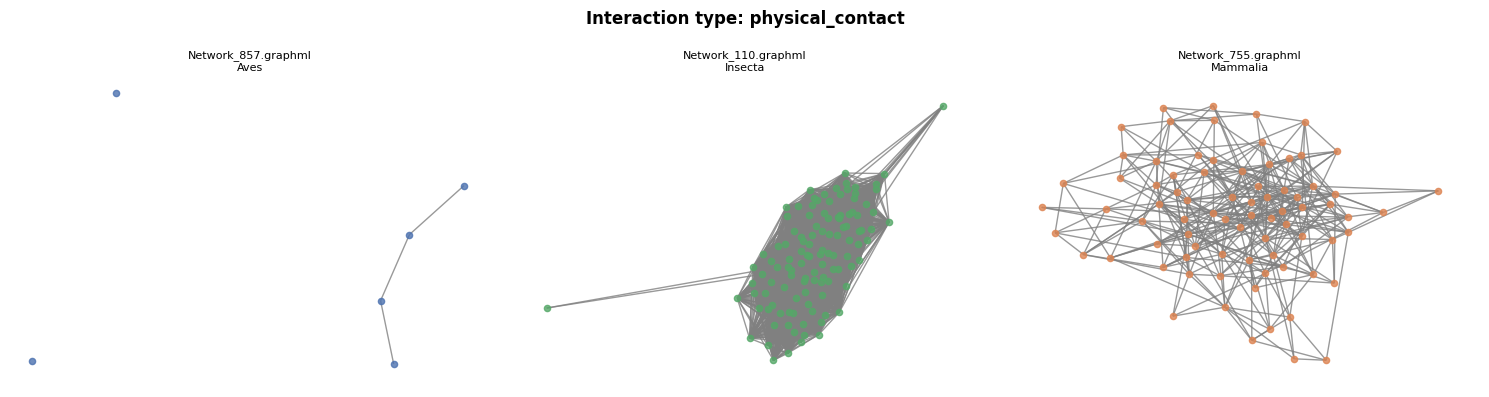

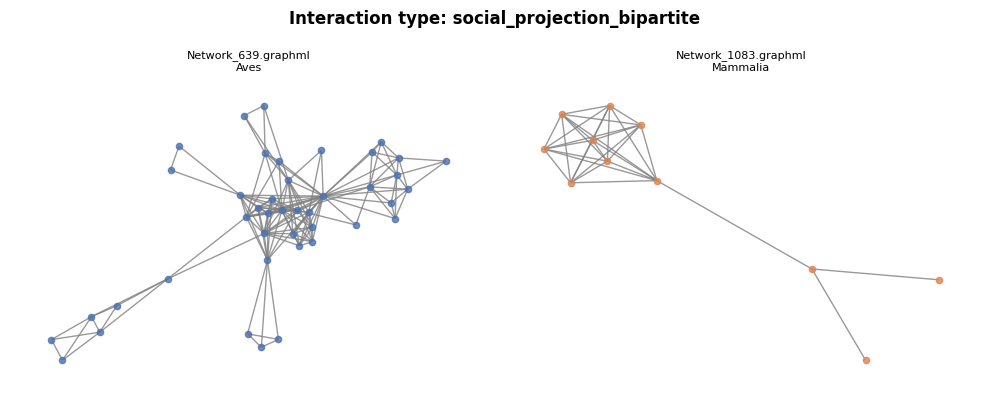

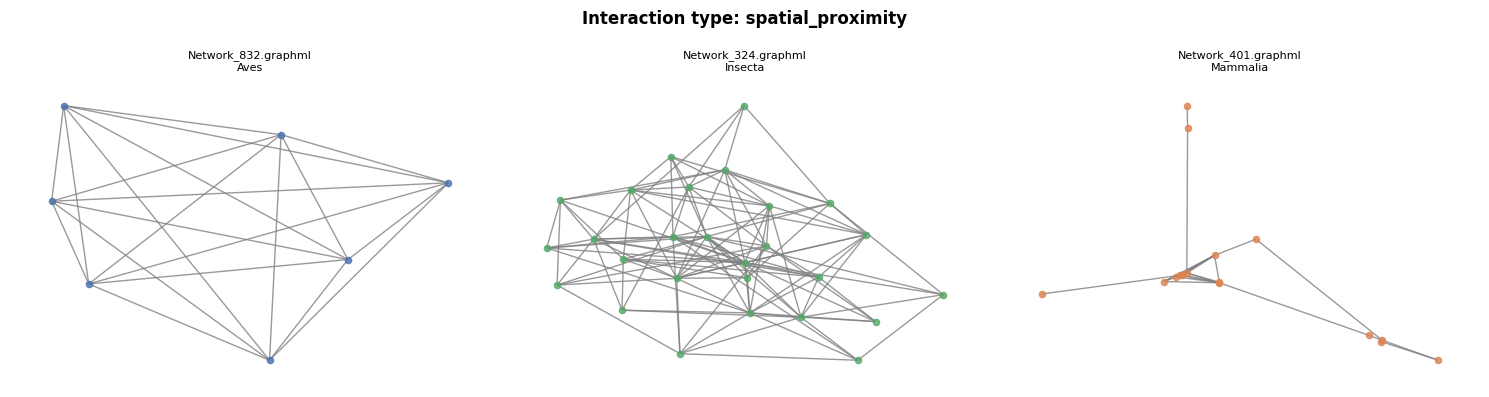

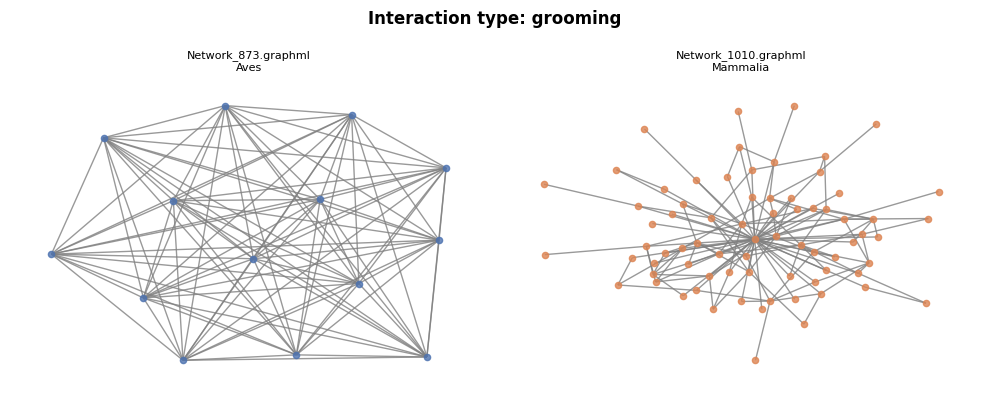

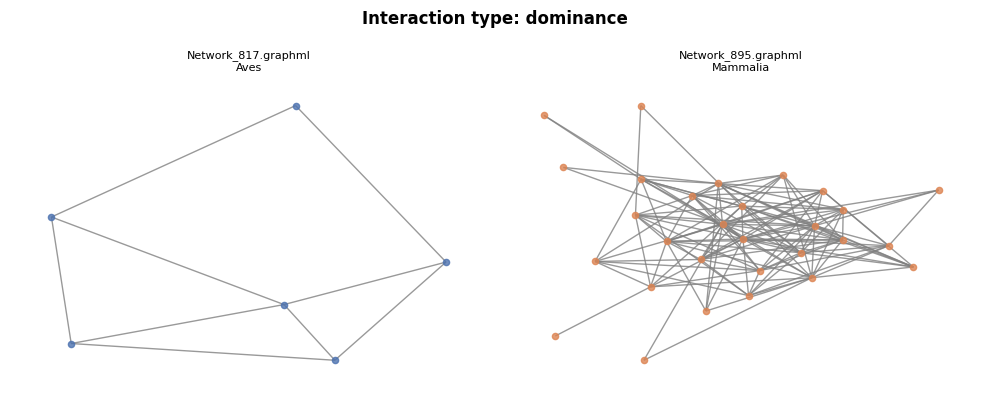

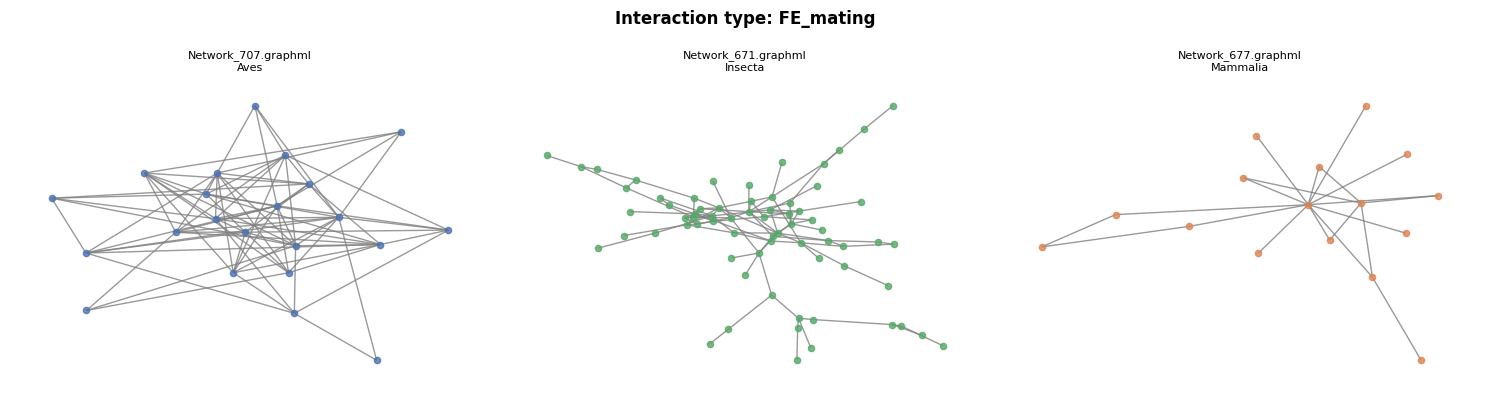

In [10]:
samples_per_group = 1
sampled_df = (
    filtered_df
    .groupby(['network_class','interaction_type'], group_keys=False)
    .sample(n=samples_per_group, random_state=124)
    .reset_index(drop=True)
)
for interaction in selected_interactions:
    subset = sampled_df[sampled_df['interaction_type']==interaction]
    if len(subset) == 0: continue
    n = len(subset)
    fig, axes = plt.subplots(1, n, figsize=(5*n, 4))
    if n == 1: axes = [axes]
    fig.suptitle(f'Interaction type: {interaction}', fontsize=12, fontweight='bold')
    for ax, (_, row) in zip(axes, subset.iterrows()):
        g = asnr_graphs[row['Network_ID']]
        nx.draw(g, ax=ax, with_labels=False, node_size=20,
                node_color=CLASS_COLORS.get(row['network_class'], 'gray'),
                edge_color='gray', alpha=0.8)
        ax.set_title(f"{row['Network_ID']}\n{row['network_class']}", fontsize=8)
    plt.tight_layout()
    plt.show()
